<a href="https://colab.research.google.com/github/a00377571/lsm-reconocimiento-mediapipe/blob/main/Avance1_E47.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Instalación de dependencias**

In [ ]:
!pip install -q mediapipe opencv-python-headless

import cv2
import pandas as pd
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import urllib.request
import os

# Descargar el modelo de detección de manos (obligatorio en la nueva API)
MODELO = "hand_landmarker.task"
if not os.path.exists(MODELO):
    url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
    urllib.request.urlretrieve(url, MODELO)
    print("✅ Modelo descargado")

print("✅ Dependencias listas")

✅ Dependencias listas


**Descarga de modelo para detección**

In [ ]:
import os
import urllib.request

RUTA_MODELO = "hand_landmarker.task"

# 1. Eliminar el archivo vacío/corrupto si existe
if os.path.exists(RUTA_MODELO):
    os.remove(RUTA_MODELO)
    print("🗑️ Archivo anterior eliminado")

# 2. Descargar de nuevo
print("📥 Descargando modelo...")
url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"

try:
    urllib.request.urlretrieve(url, RUTA_MODELO)
    print("✅ Descarga completada")
except Exception as e:
    print(f"❌ Error con urllib: {e}")
    print("🔁 Intentando con wget...")
    !wget -q --show-progress -O {RUTA_MODELO} {url}

# 3. Verificar
if os.path.exists(RUTA_MODELO):
    tamaño = os.path.getsize(RUTA_MODELO)
    print(f"📦 Tamaño: {tamaño / 1024 / 1024:.2f} MB")
    if tamaño < 1_000_000:  # menos de 1 MB = sospechoso
        print("⚠️ El archivo sigue siendo muy pequeño. Revisa la conexión.")
    else:
        print("🎉 Modelo listo para usar")
else:
    print("❌ El archivo no se descargó")

🗑️ Archivo anterior eliminado
📥 Descargando modelo...
✅ Descarga completada
📦 Tamaño: 7.46 MB
🎉 Modelo listo para usar


**Detección para manos**

Saving dos-manos.jpg to dos-manos (1).jpg


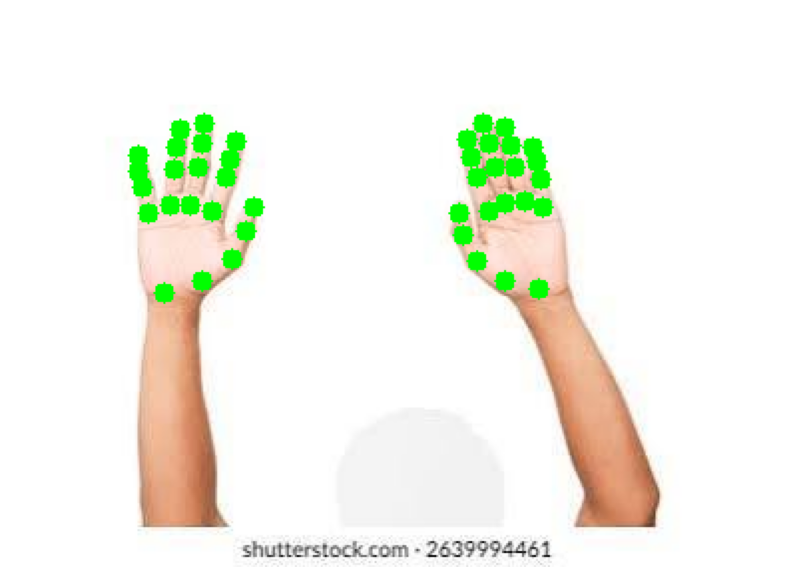

In [ ]:
def detectar_mano_imagen(ruta_imagen):
    # Configurar el detector
    base_options = mp_python.BaseOptions(model_asset_path=RUTA_MODELO)
    options = vision.HandLandmarkerOptions(
        base_options=base_options,
        num_hands=2,
        min_hand_detection_confidence=0.5
    )
    detector = vision.HandLandmarker.create_from_options(options)

    # Cargar imagen
    imagen_bgr = cv2.imread(ruta_imagen)
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

    # Crear objeto Image de MediaPipe
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=imagen_rgb)
    resultado = detector.detect(mp_image)

    # Dibujar manualmente (la nueva API no incluye drawing_utils para todo)
    if resultado.hand_landmarks:
        for hand_landmarks in resultado.hand_landmarks:
            for lm in hand_landmarks:
                h, w, _ = imagen_bgr.shape
                cx, cy = int(lm.x * w), int(lm.y * h)
                cv2.circle(imagen_bgr, (cx, cy), 5, (0, 255, 0), -1)

        # Mostrar
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()
    else:
        print("⚠️ No se detectó ninguna mano")

    return resultado

# Uso
archivos = files.upload()
ruta = list(archivos.keys())[0]
resultado = detectar_mano_imagen(ruta)

**Detección para video**

In [ ]:
def detectar_mano_video(ruta_video, ruta_salida="video_salida.mp4"):
    base_options = mp_python.BaseOptions(model_asset_path=MODELO)
    options = vision.HandLandmarkerOptions(
        base_options=base_options,
        num_hands=2,
        min_hand_detection_confidence=0.5,
        min_tracking_confidence=0.5
    )
    detector = vision.HandLandmarker.create_from_options(options)

    cap = cv2.VideoCapture(ruta_video)
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    ancho = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    alto = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(ruta_salida, fourcc, fps, (ancho, alto))

    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        resultado = detector.detect(mp_image)

        if resultado.hand_landmarks:
            for hand_landmarks in resultado.hand_landmarks:
                for lm in hand_landmarks:
                    cx, cy = int(lm.x * ancho), int(lm.y * alto)
                    cv2.circle(frame, (cx, cy), 5, (0, 255, 0), -1)

        out.write(frame)
        frame_idx += 1
        if frame_idx % 30 == 0:
            print(f"⏳ Frame {frame_idx}/{total}")

    cap.release()
    out.release()
    print(f"✅ Video guardado: {ruta_salida}")
    files.download(ruta_salida)

# Uso
archivos = files.upload()
ruta_video = list(archivos.keys())[0]
detectar_mano_video(ruta_video)

Saving Hola 1.mp4 to Hola 1 (2).mp4
⏳ Frame 30/342
⏳ Frame 60/342
⏳ Frame 90/342
⏳ Frame 120/342
⏳ Frame 150/342
⏳ Frame 180/342
⏳ Frame 210/342
⏳ Frame 240/342
⏳ Frame 270/342
⏳ Frame 300/342
⏳ Frame 330/342
✅ Video guardado: video_salida.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Extracción con features dinámicas**

In [ ]:
# Conexiones anatómicas para ángulos
ARTICULACIONES = [
    (1,2,3,"angle_thumb_mcp"),(2,3,4,"angle_thumb_ip"),(0,1,2,"angle_thumb_cmc"),
    (5,6,7,"angle_index_pip"),(6,7,8,"angle_index_dip"),(0,5,6,"angle_index_mcp"),
    (9,10,11,"angle_middle_pip"),(10,11,12,"angle_middle_dip"),(0,9,10,"angle_middle_mcp"),
    (13,14,15,"angle_ring_pip"),(14,15,16,"angle_ring_dip"),(0,13,14,"angle_ring_mcp"),
    (17,18,19,"angle_pinky_pip"),(18,19,20,"angle_pinky_dip"),(0,17,18,"angle_pinky_mcp"),
    (5,0,9,"angle_between_index_middle"),
    (9,0,13,"angle_between_middle_ring"),
    (13,0,17,"angle_between_ring_pinky"),
    (5,0,17,"angle_between_index_pinky"),
]

def calcular_angulo(a, b, c):
    ba, bc = a - b, c - b
    cos = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return float(np.degrees(np.arccos(np.clip(cos, -1, 1))))

def extraer_features_mano(hand_landmarks):
    """21 landmarks → dict con todas las features de una mano."""
    coords = np.array([[lm.x, lm.y, lm.z] for lm in hand_landmarks])
    f = {}
    # Coordenadas (63)
    for i in range(21):
        f[f"x{i}"], f[f"y{i}"], f[f"z{i}"] = coords[i]
    # Distancias desde muñeca (20)
    for i in range(1, 21):
        f[f"dist_{i}"] = float(np.linalg.norm(coords[i] - coords[0]))
    # Ángulos (19)
    for a, b, c, nombre in ARTICULACIONES:
        f[nombre] = calcular_angulo(coords[a], coords[b], coords[c])
    # Orientación (2)
    v = coords[9] - coords[0]
    f["hand_ori_x"], f["hand_ori_y"] = float(v[0]), float(v[1])
    # Muñeca (3)
    f["wrist_x"], f["wrist_y"], f["wrist_z"] = coords[0]
    return f


def extraer_frame_combinado(resultado, etiqueta, video_id, frame_id, timestamp):
    """
    Extrae features de todas las manos detectadas en un frame,
    con prefijos 'left_' y 'right_' + features de relación.
    """
    fila = {"video_id": video_id, "frame_id": frame_id,
            "timestamp": timestamp, "label": etiqueta}

    # Recolectar manos por lateralidad
    manos = {"Left": None, "Right": None}
    if resultado.hand_landmarks:
        for i, hl in enumerate(resultado.hand_landmarks):
            lado = resultado.handedness[i][0].category_name
            if manos[lado] is None:
                manos[lado] = hl

    # Features por mano (con relleno si falta)
    nombres_feats = None
    for lado in ["Left", "Right"]:
        pref = "left_" if lado == "Left" else "right_"
        hl = manos[lado]
        if hl is not None:
            feats = extraer_features_mano(hl)
            for k, v in feats.items():
                fila[pref + k] = v
            fila[pref + "detectada"] = 1
            if nombres_feats is None:
                nombres_feats = list(feats.keys())
        else:
            fila[pref + "detectada"] = 0
            if nombres_feats is None:
                nombres_feats = []  # se rellenará abajo si la otra mano existe
            for k in nombres_feats:
                fila[pref + k] = np.nan

    # Features de relación entre manos
    if manos["Left"] is not None and manos["Right"] is not None:
        L, R = manos["Left"], manos["Right"]
        def g(hl, idx):
            return np.array([hl[idx].x, hl[idx].y, hl[idx].z])
        fila["dist_munecas"]  = float(np.linalg.norm(g(L,0) - g(R,0)))
        fila["dist_indices"]  = float(np.linalg.norm(g(L,8) - g(R,8)))
        fila["dist_pulgares"] = float(np.linalg.norm(g(L,4) - g(R,4)))
        fila["dist_medios"]   = float(np.linalg.norm(g(L,12) - g(R,12)))
        fila["num_manos"]     = 2
    else:
        fila["dist_munecas"]  = np.nan
        fila["dist_indices"]  = np.nan
        fila["dist_pulgares"] = np.nan
        fila["dist_medios"]   = np.nan
        fila["num_manos"]     = int(manos["Left"] is not None) + int(manos["Right"] is not None)

    return fila

**Imagen**

In [ ]:
def procesar_imagen(ruta_imagen, etiqueta="sin_etiqueta", guardar_anotada=True):
    """
    Procesa UNA imagen y devuelve un DataFrame con una sola fila
    (mismas columnas de features que el pipeline de video, sin deltas).
    """
    # Cargar imagen
    img_bgr = cv2.imread(ruta_imagen)
    if img_bgr is None:
        raise ValueError(f"No se pudo leer la imagen: {ruta_imagen}")

    h, w = img_bgr.shape[:2]

    # Crear detector (static_image_mode implícito: no hay tracking entre frames)
    options = vision.HandLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=MODELO),
        num_hands=2,
        min_hand_detection_confidence=0.5
    )
    detector = vision.HandLandmarker.create_from_options(options)

    # Convertir a RGB y procesar
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    resultado = detector.detect(mp_image)

    # Extraer features con la MISMA función del pipeline
    fila = extraer_frame_combinado(
        resultado,
        etiqueta=etiqueta,
        video_id=0,
        frame_id=0,
        timestamp=0.0
    )
    fila["archivo"] = ruta_imagen
    fila["ancho"]   = w
    fila["alto"]    = h

    # (Opcional) guardar imagen anotada
    if guardar_anotada and resultado.hand_landmarks:
        img_anot = img_bgr.copy()
        for hl in resultado.hand_landmarks:
            for lm in hl:
                cx, cy = int(lm.x * w), int(lm.y * h)
                cv2.circle(img_anot, (cx, cy), 4, (0, 255, 0), -1)
        cv2.imwrite("imagen_anotada.jpg", img_anot)
        print("💾 Imagen anotada: imagen_anotada.jpg")

    df = pd.DataFrame([fila])
    print(f"✅ Imagen procesada: {df.shape[1]} columnas | "
          f"manos detectadas: {int(df['num_manos'].iloc[0])}")
    return df

In [ ]:
from google.colab import files

# Subir imagen
print("📤 Sube una imagen (.jpg, .png):")
archivos = files.upload()
ruta_img = list(archivos.keys())[0]

# Procesar
df_imagen = procesar_imagen(ruta_img, etiqueta="saludo")

# Vista previa
print("\n📊 Dimensiones:", df_imagen.shape)
df_imagen.iloc[:, :10]   # primeras columnas

📤 Sube una imagen (.jpg, .png):


Saving dos-manos.jpg to dos-manos.jpg
💾 Imagen anotada: imagen_anotada.jpg
✅ Imagen procesada: 228 columnas | manos detectadas: 2

📊 Dimensiones: (1, 228)


,video_id,frame_id,timestamp,label,left_x0,left_y0,left_z0,left_x1,left_y1,left_z1
0,0,0,0.0,saludo,0.68246,0.502939,9.111211e-08,0.63876,0.489121,-0.018112


**Guardar CSV para**

In [ ]:
# Guardar CSV
nombre_csv = "dataset_base.csv"
df_imagen.to_csv(nombre_csv, index=False)
print(f"💾 CSV guardado: {nombre_csv} ({df_imagen.shape[0]} filas × {df_imagen.shape[1]} columnas)")

# Descargar CSV + video anotado (si se generó)
files.download(nombre_csv)
if os.path.exists("video_anotado.mp4"):
    files.download("video_anotado.mp4")

💾 CSV guardado: dataset_base.csv (1 filas × 228 columnas)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Video**

In [ ]:
# 1. Sube el video
print("📤 Sube tu video (.mp4, .mov, .avi, .webm):")
archivos = files.upload()
ruta_video = list(archivos.keys())[0]

# 2. Procesar
df_frames = procesar_video(
    ruta_video,
    etiqueta="saludo",      # cambia esto por la etiqueta real
    video_id=0,
    cada_n_frames=1,          # 1 = todos los frames
    guardar_video_anotado=True  # genera video_anotado.mp4
)

# 3. Vista previa
print("\n📊 Dimensiones:", df_frames.shape)
print("\n🔍 Primeras columnas:")
print(df_frames.iloc[:3, :8])

📤 Sube tu video (.mp4, .mov, .avi, .webm):


Saving Hola 1.mp4 to Hola 1 (6).mp4
🎬 Video: 1280x720 @ 30.0 fps — 342 frames


Exception ignored in: <function HandLandmarker.__del__ at 0x7eacd38e1620>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/mediapipe/tasks/python/vision/hand_landmarker.py", line 603, in __del__
    self.close()
  File "/usr/local/lib/python3.13/dist-packages/mediapipe/tasks/python/vision/hand_landmarker.py", line 579, in close
    self._lib.MpHandLandmarkerClose(self._handle)
  File "/usr/local/lib/python3.13/dist-packages/mediapipe/tasks/python/core/serial_dispatcher.py", line 74, in shutdown_aware_handler
    return handler(*args, **kwargs)
  File "/usr/local/lib/python3.13/dist-packages/mediapipe/tasks/python/core/mediapipe_c_utils.py", line 142, in dispatcher_wrapper
    executor.submit(dispatch_and_free).result()
  File "/usr/lib/python3.13/concurrent/futures/thread.py", line 166, in submit
    with self._shutdown_lock, _global_shutdown_lock:
KeyboardInterrupt: 
Exception ignored in: <function HandLandmarker.__del__ at 0x7eacd38e1620>
Traceback (

KeyboardInterrupt: 

**Guardar y descargar dataset para video**

In [ ]:
# Guardar CSV
nombre_csv = "dataset_base.csv"
df_frames.to_csv(nombre_csv, index=False)
print(f"💾 CSV guardado: {nombre_csv} ({df_frames.shape[0]} filas × {df_frames.shape[1]} columnas)")

# Descargar CSV + video anotado (si se generó)
files.download(nombre_csv)
if os.path.exists("video_anotado.mp4"):
    files.download("video_anotado.mp4")

NameError: name 'df_frames' is not defined

**Procesar video**

In [ ]:
def procesar_video(ruta_video, etiqueta="sin_etiqueta", video_id=0,
                   cada_n_frames=1, guardar_video_anotado=False):
    """
    Procesa un video completo y devuelve un DataFrame (una fila por frame procesado).
    """
    options = vision.HandLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=MODELO),
        num_hands=2,
        min_hand_detection_confidence=0.5,
        min_tracking_confidence=0.5
    )
    detector = vision.HandLandmarker.create_from_options(options)

    cap = cv2.VideoCapture(ruta_video)
    if not cap.isOpened():
        raise ValueError(f"No se pudo abrir: {ruta_video}")

    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    ancho = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    alto  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"🎬 Video: {ancho}x{alto} @ {fps:.1f} fps — {total} frames")

    # (Opcional) escritor de video anotado para visualizar después
    out = None
    if guardar_video_anotado:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        out = cv2.VideoWriter("video_anotado.mp4", fourcc, fps, (ancho, alto))

    filas = []
    idx = 0
    frame_valido = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if idx % cada_n_frames == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
            res = detector.detect(mp_image)

            fila = extraer_frame_combinado(
                res, etiqueta=etiqueta, video_id=video_id,
                frame_id=frame_valido, timestamp=idx / fps
            )
            filas.append(fila)

            # Dibujar landmarks sobre el frame si vamos a exportar video
            if out is not None and res.hand_landmarks:
                for hl in res.hand_landmarks:
                    pts = [(int(lm.x*ancho), int(lm.y*alto)) for lm in hl]
                    for p in pts:
                        cv2.circle(frame, p, 4, (0,255,0), -1)
                out.write(frame)

            frame_valido += 1

        idx += 1

    cap.release()
    if out is not None:
        out.release()

    df = pd.DataFrame(filas)

    # ---- Deltas y velocidad (para gestos dinámicos) ----
    cols_mov = [c for c in df.columns
                if c.startswith(("left_x","left_y","left_z",
                                 "right_x","right_y","right_z"))]
    for c in cols_mov:
        df[f"delta_{c}"] = df[c].diff().fillna(0.0)
        df[f"vel_{c}"]   = df[f"delta_{c}"] * fps

    print(f"✅ {len(df)} frames procesados → {df.shape[1]} columnas")
    return df